# 📈 Project 2 — Will it close UP or DOWN tomorrow? (Classification)

**The question:** using only what we know *today*, can we predict whether an asset (we'll use the
S&P 500 ETF, **SPY**) closes **higher tomorrow** (up) or **not** (down)?

This is **classification** — predicting a **category** (here just two: "up" or "down"), as opposed to
Project 1's regression, which predicted a number.

> ⚠️ **Honest warning, read this first.** Real markets are *very close to random*. A simple model like
> ours should land only a little above a coin flip. That's the point — we're learning the
> **classification workflow** on data you find interesting, **not** building a money-printer. In fact,
> if you ever see a stock model with 90% accuracy, be *suspicious*: it almost always means a bug where
> future information leaked into the inputs.

## Step 0 — Import our tools

New faces compared to Project 1:
- **yfinance** — downloads real historical prices from Yahoo Finance.
- **os** — lets us save/load a local copy of the data so the notebook re-runs offline.
- Several **classifier** models from scikit-learn, plus tools to grade them.

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Three different classifier models, so we can compare them:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression works best when features are on a similar scale,
# so we bundle a scaler + the model together with a Pipeline.
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Grading tools:
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

print("Tools imported ✅")

Tools imported ✅


## Step 1 — Get the price data (and cache it)

We download a few years of daily prices for our ticker. The first run fetches from Yahoo Finance and
saves a copy into `../data/`; after that, the notebook loads the local copy (so it works offline).

👉 Want a different asset later? Change `ticker` below to e.g. `"AAPL"`, `"MSFT"`, `"BTC-USD"`.

In [ ]:
ticker = "SPY"          # <-- change this to try another asset
period = "5y"           # <-- change this to try another period
interval = "1d"         # <-- change this to try another interval

data_folder = "../data"
os.makedirs(data_folder, exist_ok=True)
cache_file = f"{data_folder}/{ticker}_prices.csv"

if os.path.exists(cache_file):
    print("Loading cached data from", cache_file)
    prices = pd.read_csv(cache_file, index_col=0, parse_dates=True)
else:
    print("Downloading", ticker, "from Yahoo Finance...")
    prices = yf.download(ticker, period=period, interval=interval,
                         auto_adjust=True, progress=False)
    # yfinance returns 2-level column names like ("Close", "SPY"); flatten to just "Close".
    prices.columns = prices.columns.get_level_values(0)
    prices.to_csv(cache_file)
    print("Saved a copy to", cache_file, "(future runs will be offline).")

print("Trading days loaded:", len(prices))
prices.tail()

Loading cached data from ../data/SPY_prices.csv
Trading days loaded: 1254


,Close,High,Low,Open,Volume
Date,,,,,
2026-06-17,739.056030,750.217279,737.320450,749.359442,85945200
2026-06-18,746.739990,748.229980,743.859985,747.760010,80875700
2026-06-22,744.390015,750.179993,743.130005,747.700012,46628100
2026-06-23,733.580017,739.630005,732.299988,733.809998,66846800
2026-06-24,733.239990,739.950012,730.840027,735.169983,56924000


## Step 2 — Build features (what the model gets to look at)

A raw price isn't very useful on its own. We engineer **features** that describe recent *behavior* —
all computed from today and earlier, never the future:

| Feature | Meaning |
|---------|---------|
| `daily_return` | how much the price moved today vs. yesterday |
| `return_5d` | total move over the last 5 days |
| `momentum_10` | move over the last 10 days |
| `price_vs_ma10` | how far today's price is above/below its 10-day average |
| `volatility_10` | how jumpy the last 10 days have been |
| `volume_change` | change in how much was traded |

In [4]:
prices["daily_return"]  = prices["Close"].pct_change()
prices["return_5d"]     = prices["Close"].pct_change(5)
prices["momentum_10"]   = prices["Close"] / prices["Close"].shift(10) - 1
prices["moving_avg_10"] = prices["Close"].rolling(10).mean()
prices["price_vs_ma10"] = prices["Close"] / prices["moving_avg_10"] - 1
prices["volatility_10"] = prices["daily_return"].rolling(10).std()
prices["volume_change"] = prices["Volume"].pct_change()

feature_columns = ["daily_return", "return_5d", "momentum_10",
                   "price_vs_ma10", "volatility_10", "volume_change"]
prices[feature_columns].tail()

,daily_return,return_5d,momentum_10,price_vs_ma10,volatility_10,volume_change
Date,,,,,,
2026-06-17,-0.012488,0.021408,-0.017607,-0.001667,0.013884,0.280984
2026-06-18,0.010397,0.014780,-0.011130,0.009860,0.014324,-0.058985
2026-06-22,-0.003147,0.006145,0.011874,0.005494,0.011477,-0.423460
2026-06-23,-0.014522,-0.025648,-0.005073,-0.008607,0.012493,0.433616
2026-06-24,-0.000464,-0.020259,-0.002606,-0.008810,0.012463,-0.148441


## Step 3 — Build the target (what we're trying to predict)

The label is simple: **did tomorrow close higher than today?**
`1` = up, `0` = down. We get "tomorrow" by shifting the close price back by one day.

In [5]:
# tomorrow's close, lined up next to today's row
prices["tomorrow_close"]   = prices["Close"].shift(-1)
prices["went_up_tomorrow"] = (prices["tomorrow_close"] > prices["Close"]).astype(int)

# Drop rows with missing values (the first rows have no history; the last has no tomorrow).
model_data = prices.dropna()

asset_features = model_data[feature_columns]   # books call this 'X'
went_up        = model_data["went_up_tomorrow"]  # books call this 'y'

up_share = went_up.mean()
print(f"Usable trading days: {len(model_data)}")
print(f"Days that went up:   {up_share:.1%}  (so 'down' days are {1 - up_share:.1%})")

Usable trading days: 1243
Days that went up:   54.2%  (so 'down' days are 45.8%)


## Step 4 — Split by TIME (not randomly!)

In Project 1 we shuffled the data randomly. **With time series we must NOT do that** — shuffling would
let the model peek at the future to predict the past, which is cheating (called *look-ahead leakage*).

Instead we train on the **earlier** 80% of days and test on the **most recent** 20% — exactly how you'd
have to use it in real life.

In [5]:
split_index = int(len(model_data) * 0.8)

training_features = asset_features.iloc[:split_index]
test_features     = asset_features.iloc[split_index:]
training_labels   = went_up.iloc[:split_index]
test_labels       = went_up.iloc[split_index:]

print("Train on days:", training_features.index.min().date(), "->", training_features.index.max().date())
print("Test  on days:", test_features.index.min().date(), "->", test_features.index.max().date())

Train on days: 2021-07-12 -> 2025-06-25
Test  on days: 2025-06-26 -> 2026-06-23


## Step 5 — A baseline to beat

Before fancy models, ask: **how well does a dumb guess do?** If we always predict the more common
outcome, what accuracy do we get? Any real model has to beat *this* to be worth anything.

In [6]:
baseline_guess = training_labels.mode()[0]          # the more common class in training
baseline_accuracy = (test_labels == baseline_guess).mean()
print(f"Always guess '{'up' if baseline_guess == 1 else 'down'}' -> "
      f"baseline accuracy = {baseline_accuracy:.1%}")

Always guess 'up' -> baseline accuracy = 55.4%


## Step 6 — Train three models and compare them

Each model learns differently:
- **Logistic Regression** — draws a straight boundary between "up" and "down" (with scaling).
- **Decision Tree** — asks a series of yes/no questions about the features.
- **Random Forest** — a crowd of many trees voting together (usually the strongest of the three).

In [7]:
models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "Decision Tree":        DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest":        RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42),
}

accuracy_by_model = {}
for name, model in models.items():
    model.fit(training_features, training_labels)            # learn from training days
    predictions = model.predict(test_features)              # guess the test days
    accuracy_by_model[name] = accuracy_score(test_labels, predictions)

results = pd.Series(accuracy_by_model).sort_values(ascending=False)
print(f"(Baseline to beat: {baseline_accuracy:.1%})\n")
print((results * 100).round(1).astype(str) + "%")

(Baseline to beat: 55.4%)

Logistic Regression    54.2%
Random Forest          54.2%
Decision Tree          47.8%
dtype: str


## Step 7 — Look closer at the Random Forest

**Accuracy** alone hides *what kind* of mistakes a model makes. A **confusion matrix** shows all four
cases: correctly-up, correctly-down, and the two kinds of wrong. The diagonal is where it got it right.

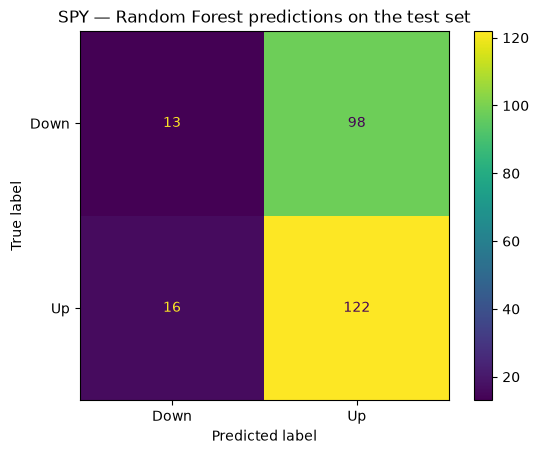

In [8]:
forest = models["Random Forest"]
forest_predictions = forest.predict(test_features)

ConfusionMatrixDisplay.from_predictions(
    test_labels, forest_predictions, display_labels=["Down", "Up"]
)
plt.title(f"{ticker} — Random Forest predictions on the test set")
plt.show()

And which features did the forest lean on most? (This is the model's opinion, not financial truth.)

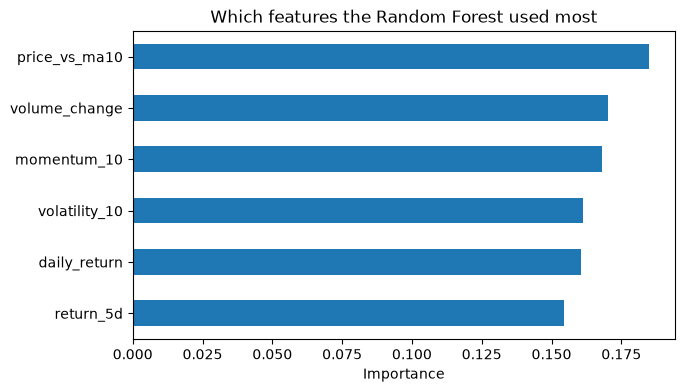

In [9]:
feature_importance = pd.Series(
    forest.feature_importances_, index=feature_columns
).sort_values()

feature_importance.plot(kind="barh", figsize=(7, 4), title="Which features the Random Forest used most")
plt.xlabel("Importance")
plt.show()

## Step 8 — So... did it work?

Look at Step 6: the models almost certainly landed **near the baseline** (just a hair above or even
below a coin flip). **That is the correct, honest result** — daily market direction is close to
unpredictable from price history alone. What you *practiced* here is the real skill:

- turning raw data into **features**,
- building a **classification target**,
- splitting by **time** to avoid leakage,
- comparing **multiple models** against a **baseline**,
- reading a **confusion matrix**.

These steps are identical for problems that *are* very predictable (spam, fraud, medical tests) — you've
now got the whole workflow.

## Step 9 — 🧪 Your turn

1. Change `ticker` in **Step 1** to `"AAPL"` or `"BTC-USD"` and *Run All*. Does accuracy beat the baseline?
2. In **Step 4**, what happens if you (wrongly!) shuffle the split? Try
   `train_test_split(asset_features, went_up, test_size=0.2, random_state=42)` and watch accuracy jump —
   that jump is the *leakage* we warned about, not real skill.
3. In **Step 2**, invent a new feature (e.g. a 20-day moving-average ratio) and add it to `feature_columns`.

Scratchpad below 👇

In [10]:
# 🧪 Your experiments go here:
